# 02. Feature Engineering — EDA 결론을 입력 변수로 구현

DAY 1 보고서의 「모델 설계 전략 §1 Feature Engineering」을 코드로 옮깁니다.

| 보고서 결정 | 구현 (`src/features.py`) |
|---|---|
| `ln Var[ΔQ₁₀₀₋₁₀(V)]`를 단일 피처 기준 모델의 입력으로 | `BASE = ['ln_dq_variance']` |
| `dq_min`은 로그 분산과 중복(ρ = −0.996) → 기본 입력에서 제외 | 어떤 세트에도 넣지 않음 |
| 10·100회 Qd, IR, 평균 전류가 쌍으로 겹침 → 각 쌍에서 하나만 | `qd_100`, `ir_100`, `charge_current_10` |
| 충전 정책·전류는 기본 피처로 고정하지 않고 추가 효과를 별도 검증 | `GROUPS['charging']` — 다른 그룹과 같이 "검증 오차를 줄일 때만" 채택 |
| 10–100회 Qd 기울기와 100회 Qd는 추가 실험 후보, 검증 오차를 줄일 때만 채택 | `GROUPS['fade']`, `GROUPS['capacity']` |
| 후반 열화율·knee는 초기 예측 입력에서 제외 | 피처 목록에 없음 (EDA 전용 컬럼) |

분할은 과제 기준인 **Batch 1 학습 → Batch 2 평가(GAP 대상)**입니다. 보고서의 "배치별 검증 오차" 규칙을 지키기 위해 **Batch 3는 모델 선택용 검증 배치**로 씁니다.

먼저 프로젝트 루트에서 `python src/preprocess.py`를 실행하세요.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
from features import ALL_FEATURES, BASE, GROUPS, load_cells, split

FIG = ROOT / 'figures'
BATCH_STYLE = {'Batch 1': ('#2a78d6', 'o'), 'Batch 2': ('#eb6834', 's'), 'Batch 3': ('#1baf7a', '^')}
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 160)

cells = load_cells()
data = split(cells)
pd.DataFrame({name: {'batch': f.batch.iloc[0], 'cells': len(f),
                     'life min': int(f.cycle_life.min()), 'life median': f.cycle_life.median(),
                     'life max': int(f.cycle_life.max()), '<500 cycles': int((f.cycle_life < 500).sum())}
              for name, f in data.items()}).T

,batch,cells,life min,life median,life max,<500 cycles
train,Batch 1,36,534,772.5,1074,0
test,Batch 2,39,392,472.0,1186,28
secondary,Batch 3,44,541,1005.5,1935,0


## 1. 데이터 분할과 정제 규칙

| 규칙 | 근거 |
|---|---|
| 수명 라벨 결측 10셀 제외 (Batch 2의 VarCharge·SLOWCYCLE 프로토콜) | 라벨 없음 |
| Batch 1의 10셀 제외 | 라벨 = 마지막 기록 사이클 + 1인데 마지막 Qd > 0.885 Ah → 0.88 Ah 도달 전에 기록이 끝난 **우측 중도절단** 값 |
| 셀 단위 분할, 배치 단위 학습/평가 | 같은 셀의 사이클이 학습·평가에 섞이지 않음 |
| 결측 대체·표준화는 sklearn `Pipeline` 안에서 학습 데이터에만 fit | 평가 배치 정보 누수 방지 |

**주의할 분할 특성.** 학습(Batch 1)의 수명은 534–1,074회인데, 평가(Batch 2) 39셀 중 30셀은 534회보다 짧습니다. 따라서 Batch 2 평가는 **학습 범위 밖 외삽**을 포함하며, 이 점이 이후 GAP 해석의 출발점입니다.

## 2. 구현 중 발견한 기록 오류와 정제

모델 입력을 점검하다가 DAY 1 EDA가 놓친 로거 오류를 발견했습니다. 사이클 10–100 구간에서 충전시간이 419–3,934분으로 기록된 사이클이 있습니다(정상 9–14분, 실험 일시정지). `1_19`의 40번째 사이클 Qd는 2.9 Ah로 기록돼 있습니다(공칭 1.1 Ah). 평균과 선형 기울기는 이런 값 하나에도 크게 흔들립니다.

- DAY 1 컬럼(`early_charge_time_mean`, `early_qd_slope`)은 제출한 보고서의 재현을 위해 **그대로 둡니다**.
- 모델에는 정제 버전 `early_charge_time_clean`(60분 초과 기록 제외)과 `early_qd_slope_clean`(Qd ≥ 1.3 Ah 제외)을 씁니다.
- Batch 2의 신규 구조 6셀(`2_42`–`2_47`)은 IR이 기록되지 않아(0) 학습 중앙값으로 대체됩니다(`Pipeline` 안의 `SimpleImputer`).

In [2]:
diff = cells.assign(charge_time_change=cells.early_charge_time_mean - cells.early_charge_time_clean,
                    slope_change=cells.early_qd_slope - cells.early_qd_slope_clean)
affected = diff[(diff.charge_time_change.abs() > .01) | (diff.slope_change.abs() > 1e-7)]
print('Affected cells by batch:', affected.batch.value_counts().sort_index().to_dict())
affected[['cell_id', 'batch', 'early_charge_time_mean', 'early_charge_time_clean',
          'early_qd_slope', 'early_qd_slope_clean']].round(6)

Affected cells by batch: {'Batch 1': 4, 'Batch 2': 10}


,cell_id,batch,early_charge_time_mean,early_charge_time_clean,early_qd_slope,early_qd_slope_clean
0,1_06,Batch 1,15.437651,10.955632,0.000002,0.000002
5,1_15,Batch 1,15.291829,10.797410,0.000016,0.000016
6,1_16,Batch 1,15.291006,10.795647,0.000017,0.000017
9,1_19,Batch 1,9.925855,9.925855,-0.000496,-0.000062
50,2_15,Batch 2,53.367222,10.241245,-0.000100,-0.000100
56,2_21,Batch 2,53.276475,10.172960,0.000028,0.000028
60,2_27,Batch 2,53.303939,10.194860,-0.000009,-0.000009
62,2_29,Batch 2,53.289495,10.173421,0.000051,0.000051
64,2_31,Batch 2,53.311883,10.199785,-0.000089,-0.000089
66,2_33,Batch 2,53.155371,10.040929,-0.000077,-0.000077


In [3]:
pd.Series({'BASE': ', '.join(BASE), **{f'GROUPS[{k}]': ', '.join(v) for k, v in GROUPS.items()}},
          name='features').to_frame()

,features
BASE,ln_dq_variance
GROUPS[fade],early_qd_slope_clean
GROUPS[capacity],qd_100
GROUPS[resistance],ir_100
GROUPS[temperature],early_tavg_mean
GROUPS[charging],"c1, switch_soc, c2, charge_current_10, early_c..."


## 3. 피처의 수명 신호 대 배치 이동

좋은 피처는 두 조건을 함께 만족해야 합니다.

1. **학습 배치 안에서** 수명과 관계가 강하다: Batch 1에서 log 수명과의 Spearman |ρ|.
2. **평가 배치에서 분포가 크게 움직이지 않는다**: Batch 2·3 중앙값이 Batch 1 중앙값에서 Batch 1 표준편차의 몇 배만큼 떨어져 있는지(이동 z).

이동이 큰 피처는 학습 배치에서 배운 계수를 그대로 쓰면 평가 배치에서 편향이 생깁니다.

In [4]:
train = data['train']
candidates = ALL_FEATURES + ['early_charge_time_mean']  # last one: uncleaned DAY 1 column, for contrast
rows = []
for f in candidates:
    rho = spearmanr(train[f], np.log10(train.cycle_life), nan_policy='omit').statistic
    sd = train[f].std()
    rows.append({'feature': f, 'rho_batch1': rho,
                 'shift_z_batch2': (data['test'][f].median() - train[f].median()) / sd,
                 'shift_z_batch3': (data['secondary'][f].median() - train[f].median()) / sd,
                 'group': next((g for g, fs in GROUPS.items() if f in fs), 'base' if f in BASE else 'raw (DAY 1)')})
signal = pd.DataFrame(rows).set_index('feature')
signal['abs_rho'] = signal.rho_batch1.abs()
signal = signal.sort_values('abs_rho')
signal.round(2).sort_values('abs_rho', ascending=False)

,rho_batch1,shift_z_batch2,shift_z_batch3,group,abs_rho
feature,,,,,
ln_dq_variance,-0.83,1.29,-1.67,base,0.83
early_qd_slope_clean,0.50,1.18,0.02,fade,0.50
charge_current_10,-0.49,-1.60,1.11,charging,0.49
early_charge_time_mean,0.48,-0.49,-0.57,raw (DAY 1),0.48
early_charge_time_clean,0.43,-0.77,-0.93,charging,0.43
qd_100,0.37,2.10,-1.63,capacity,0.37
ir_100,0.25,-0.89,-2.73,resistance,0.25
c1,-0.24,-0.78,-0.68,charging,0.24
c2,-0.16,1.39,1.08,charging,0.16


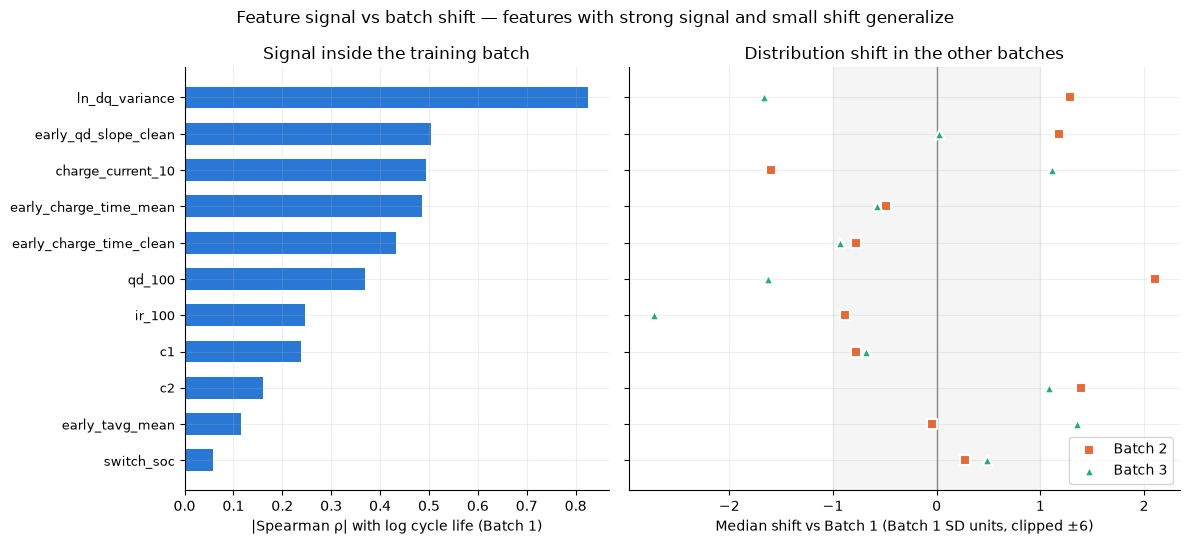

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True, gridspec_kw={'width_ratios': [1, 1.3]})
y = np.arange(len(signal))
ax1.barh(y, signal.abs_rho, color='#2a78d6', height=.6)
ax1.set_yticks(y, signal.index, fontsize=9)
ax1.set_xlabel('|Spearman ρ| with log cycle life (Batch 1)')
ax1.set_title('Signal inside the training batch')
for b, key in (('Batch 2', 'shift_z_batch2'), ('Batch 3', 'shift_z_batch3')):
    color, marker = BATCH_STYLE[b]
    ax2.scatter(signal[key].clip(-6, 6), y, color=color, marker=marker, s=48, label=b,
                edgecolor='white', linewidth=1.5, zorder=3)
ax2.axvline(0, color='#888', lw=1)
ax2.axvspan(-1, 1, color='#888', alpha=.08)
ax2.set_xlabel('Median shift vs Batch 1 (Batch 1 SD units, clipped ±6)')
ax2.set_title('Distribution shift in the other batches')
ax2.legend(loc='lower right')
fig.suptitle('Feature signal vs batch shift — features with strong signal and small shift generalize')
fig.tight_layout()
fig.savefig(FIG / 'fe1_feature_signal_vs_shift.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 핵심 변수: ln Var[ΔQ₁₀₀₋₁₀(V)]와 수명

DAY 1에서 고른 기준 피처를 배치별로 다시 확인합니다. 실선은 Batch 1에만 맞춘 log–log 직선이며, 점선 영역은 Batch 1 학습 범위 밖입니다.

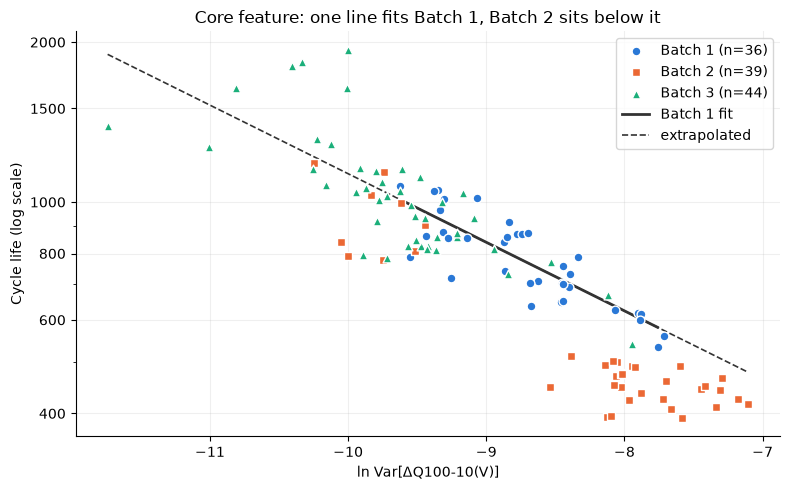

,n,spearman,median_log_residual,median_ratio_true_over_fit
batch,,,,
Batch 1,36,-0.826,-0.004,0.990
Batch 2,39,-0.709,-0.120,0.758
Batch 3,44,-0.797,-0.009,0.979


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
x_tr, y_tr = train.ln_dq_variance, np.log10(train.cycle_life)
slope, intercept = np.polyfit(x_tr, y_tr, 1)
for b, (color, marker) in BATCH_STYLE.items():
    part = cells[cells.batch == b]
    ax.scatter(part.ln_dq_variance, part.cycle_life, color=color, marker=marker, s=40, label=f'{b} (n={len(part)})',
               edgecolor='white', linewidth=1, zorder=3)
grid = np.linspace(cells.ln_dq_variance.min(), cells.ln_dq_variance.max(), 100)
inside = (grid >= x_tr.min()) & (grid <= x_tr.max())
ax.plot(grid[inside], 10 ** (intercept + slope * grid[inside]), color='#333', lw=2, label='Batch 1 fit')
ax.plot(grid, 10 ** (intercept + slope * grid), color='#333', lw=1.2, ls='--', label='extrapolated')
ax.set_yscale('log')
ax.set_yticks([400, 600, 800, 1000, 1500, 2000], ['400', '600', '800', '1000', '1500', '2000'])
ax.set_xlabel('ln Var[ΔQ100-10(V)]')
ax.set_ylabel('Cycle life (log scale)')
ax.set_title('Core feature: one line fits Batch 1, Batch 2 sits below it')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'fe2_variance_feature_by_batch.png', dpi=150, bbox_inches='tight')
plt.show()

offset = cells.assign(resid=np.log10(cells.cycle_life) - (intercept + slope * cells.ln_dq_variance))
summary = offset.groupby('batch').agg(
    n=('cell_id', 'size'),
    spearman=('ln_dq_variance', lambda s: spearmanr(s, cells.loc[s.index, 'cycle_life']).statistic),
    median_log_residual=('resid', 'median'))
summary['median_ratio_true_over_fit'] = 10 ** summary.median_log_residual
summary.round(3)

## 5. 정리: 어떤 피처를 모델에 넣는가

결론 셀의 수치는 위 표에서 그대로 읽은 값입니다.